In [ ]:
%load_ext autoreload
%autoreload 2

%gui qt

INFO:OpenGL.acceleratesupport:No OpenGL_accelerate module loaded: No module named 'OpenGL_accelerate'


In [2]:
import os
import sys
import importlib
import cv2
import time

gui_source_dir = os.path.expanduser("~/Documents/talmolab/repos/lucid_lite/gui_source")
josh_source_dir = os.path.expanduser("~/Documents/talmolab/repos/lucid_lite")

# add folders to Python's system path so it can find local imports
if gui_source_dir not in sys.path:
    sys.path.insert(0, gui_source_dir)
    sys.path.insert(0, josh_source_dir)

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tqdm import tqdm
from collections import defaultdict

import numpy as np
import pandas as pd
import sleap_io as sio
from scipy.optimize import linear_sum_assignment

from PySide6.QtGui import QImage

from lucid_lite.gui_source import graph_window
from graph_window import GroupGraphWindow

from lucid_lite.gui_source import main
from lucid_lite.gui_source import colors
from lucid_lite.gui_source.pose_data import Identity  
from lucid_lite.gui_source.colors import next_palette_color     

from lucid_lite.josh_source import geometry
from lucid_lite.josh_source import track_push
from lucid_lite.josh_source import tracker
from lucid_lite.josh_source import graphs
import luc3d_tracker_helper as lt

In [3]:
app, window = main.main(
    [
        "main.py",                                                          
        "/Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420_small"
    ]
)
# define globals
session = window.session

SKEL = session.skeleton
TRACK_COLOR_MAP = {track: colors.get_track_color(n) for n, track in enumerate(session.tracks)}
CAMERAS = {camera.name: camera for camera in session.cameras}


palette = {
    0: ('id_0', '#ff3300'),
    1: ('id_1', '#3366ff'),
    2: ('id_2', '#00ff00'),
    3: ('id_3', '#cc00cc'),
}

node_weights = {
    'Nose':   0.7,
    'Ear_R':  0.7,
    'Ear_L':  0.7,
    'TTI':    1,
    'TailTip':0,
    'Head':   1,
    'Trunk':  0.8,
    'Tail_0': 0,
    'Tail_1': 0,
    'Tail_2': 0,
    'Shoulder_left':  0.7,
    'Shoulder_right': 0.7,
    'Haunch_left':    0.7,
    'Haunch_right':   0.7,
    'Neck': 0.7
}


objc[63445]: Class AVFFrameReceiver is implemented in both /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x12386c3a8) and /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x1324a83a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[63445]: Class AVFAudioReceiver is implemented in both /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x12386c3f8) and /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x1324a83f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


Error reconstructing FrameGroup: {'frame_idx': 0, 'instance_groups': [{'identity_idx': 2, 'points': [[48.274210531915045, -32.83364109623553, 1151.7922172896963], [83.07571957116458, -20.36973935475563, 1122.5767561306118], [48.60493063151847, -9.609941024846487, 1114.0203336967766], [118.1938555894995, 62.41805188430688, 1127.1038565057063], None, [63.183150565422935, -19.64047653555298, 1119.002217769748], [87.95001857752469, 28.003282991643157, 1113.8276833747993], [130.5468355849119, 98.39776894094688, 1127.8148572723746], [134.4872571635714, 120.10234736402975, 1114.5880371853975], [123.79095702963008, 147.5698802676192, 1119.798072697085], [45.2962926550307, -1.5282608506390873, 1138.1616990219975], [77.91839844248832, -15.904808598982878, 1147.9461334695127], [78.08237333977365, 56.15708812863012, 1134.041451388676], [110.51038828679032, 21.380386282260435, 1140.5983908960961], [66.71531746227073, -10.19857028548516, 1115.945911835526]], 'instances': {'0': {'Nose': [893.38220214

In [ ]:
'''
tracker flaws:

1. everything depends on the first and second 'pivot' frames, which
    are determined by the number of instances in the view, nothing
    about the quality of the views
2. if there is a singleton group from the first two frames, then
    they remain as a singleton group
3. order-dependent recruitment: the ordering of the cameras that are
    seen after the first 2 views also matters in terms of adding to the group
        eg. cam3 then cam4 is seen, cam4's addition to the same group
        can be influenced by cam3's additions
    - subpoint: NO ALGORITHM TO DETERMINE THE ORDER OF CAMERAS
4. why do hungarian on negative of score matrix???
5. reproj error: not using the distored points

'''

"\ntracker flaws:\n\n1. everything depends on the first and second 'pivot' frames, which\n    are determined by the number of instances in the view, nothing\n    about the quality of the views\n2. if there is a singleton group from the first two frames, then\n    they remain as a singleton group\n3. order-dependent recruitment: the ordering of the cameras that are\n    seen after the first 2 views also matters in terms of adding to the group\n        eg. cam3 then cam4 is seen, cam4's addition to the same group\n        can be influenced by cam3's additions\n    - subpoint: NO ALGORITHM TO DETERMINE THE ORDER OF CAMERAS\n4. why do hungarian on negative of score matrix???\n5. reproj error: not using the distored points\n\n"

# Old Tracker (Compare Against Lucid Lite)

In [ ]:
importlib.reload(tracker_old)


curr_frame = window._current_frame
fg = session.frame_group(curr_frame)
cam_instances, cam_map, active_cams = tracker_old.get_instances(fg, session.cameras)

NameError: name 'tracker_old' is not defined

In [ ]:
# from scipy.optimize import linear_sum_assignment
importlib.reload(geometry_old)
importlib.reload(tracker_old)

inst1 = cam_instances['back'][1]
inst2 = cam_instances['midL'][1]
cache=tracker_old.TrackerCache()
# # geometry.calc_epipolar_score(
# #     inst1, cam_map['back'],
# #     inst2, cam_map['midL'],
# #     cache
# # )

error = geometry_old.calc_reprojection_score(
    inst1, cam_map['back'],
    inst2, cam_map['midL'],
    cache
)
error

# test triangulation and reprojection
# gp = {'back': inst1, 'midL': inst2}
# X = geometry.triangulate_group(gp, cam_map, cache)
# reprojs = geometry.reproject_points(X, cache.getP(cam_map['back']))
# reproj_error = geometry.instance_pixel_distance(reprojs, inst1)
fg = session.frame_group(67)
pairs = tracker_old.match_pairwise(fg, session, cache, num_animals=4)
pairs
#

INFO:root:cam1: backL, cam2: midL


[{'backL': Instance(points=[(688.61572265625, 484.5345153808594), (636.6748657226562, 470.7451477050781), (662.8090209960938, 436.68377685546875), None, None, (656.6552734375, 458.6086730957031), (600.4605712890625, 400.542236328125), None, None, None, (660.548828125, 440.7054748535156), (626.4085083007812, 472.7599792480469), (628.6024169921875, 396.9112548828125), (588.7112426757812, 440.4897766113281), (642.828125, 448.51275634765625)], track_idx=0, type='predicted', score=0.9556068181991577),
  'midL': Instance(points=[(494.644775390625, 656.7603759765625), (544.8841552734375, 678.7184448242188), (506.7277526855469, 706.5262451171875), None, None, (520.9899291992188, 686.3880615234375), (560.6146240234375, 768.4002685546875), None, None, None, (507.0426025390625, 716.6810913085938), (554.7294921875, 694.4263305664062), (528.5979614257812, 782.6134033203125), (590.88427734375, 750.6467895507812), (532.7678833007812, 704.651123046875)], track_idx=0, type='predicted', score=0.93367421

In [ ]:

import importlib; importlib.reload(lt)
# lt.triangulate_group(gp, cam_map, caches=lt.TrackerCaches())[0]
cam_instances, cam_map, active_cams = lt.collect_instances(fg, session.cameras)
# cost3 = lt.match_pairwise(cam_instances, cam_map, active_cams, num_animals=4, prev_assignments=None, caches=lt.TrackerCaches())
groups = lt.match_pairwise(fg, session, caches=lt.TrackerCaches(), num_animals=4)
groups

In [ ]:
results = lt.match_frame_instances(fg, session.cameras, session, caches=lt.TrackerCaches(), num_animals=4)
results['groups']
results['num_identities']
results['assignments']
results['targets3d'][0]



{'points3d': [array([  45.98249424,  -29.27086891, 1167.34859526]),
  array([ 3.34814615e-01, -4.47504862e+01,  1.15587883e+03]),
  array([  24.18922965,  -72.03577921, 1160.08240192]),
  array([ -46.58702995, -117.76207823, 1212.32401048]),
  array([-142.66722279,   16.56764548, 1201.73886826]),
  array([  17.97995723,  -53.32675225, 1158.39267635]),
  array([ -26.77470922, -107.01311231, 1166.57181135]),
  None,
  None,
  None,
  array([  24.42232077,  -71.50424953, 1189.06565649]),
  array([  -7.99694501,  -41.60166581, 1184.40709408]),
  array([  -7.77781823, -118.69065268, 1203.33057641]),
  array([ -44.10837824,  -75.41477364, 1198.28401833]),
  array([   6.63303986,  -63.60846938, 1161.17581981])],
 'groupIdx': 0,
 'prevInstances': {'backL': Instance(points=[(688.61572265625, 484.5345153808594), (636.6748657226562, 470.7451477050781), (662.8090209960938, 436.68377685546875), None, None, (656.6552734375, 458.6086730957031), (600.4605712890625, 400.542236328125), None, None, None,

# Tracker - Looking at Individual Frames

In [28]:
importlib.reload(geometry)
importlib.reload(tracker)

projcache = tracker.ProjCache()

frames = []
n = window.session.max_frame
now = time.time()
for i in tqdm(range(n)):
    fg = session.frame_group(i)
    sft = tracker.SingleFrameTrack(fg, session.cameras, node_weights=node_weights, proj_cache=projcache)
    frames.append(sft)
finish = time.time()

# calculate states
delta_t = finish-now
invalid_frames = [f.frame_idx for f in frames if not f.valid]
n_valid = sum([f.valid for f in frames])

print(f'Completed running {n} frames in {delta_t:.3f} seconds for an average of {delta_t/n:.3f} secs/frame')
print(f'Stats:\n' \
        f'num valid: {n_valid}\n'
        f'num invalid: {n-n_valid}\n'
        f'percent valid: {n_valid/n}\n'
        f'invalid frames: {invalid_frames}'
)

 61%|██████    | 1091/1799 [00:05<00:03, 212.75it/s]/Users/joshuapark/Documents/talmolab/repos/lucid_lite/josh_source/geometry.py:188: RuntimeWarning: Mean of empty slice
  return np.nanmean(norms)
100%|██████████| 1799/1799 [00:08<00:00, 209.29it/s]

Completed running 1799 frames in 8.636 seconds for an average of 0.005 secs/frame
Stats:
num valid: 1799
num invalid: 0
percent valid: 1.0
invalid frames: []


In [37]:
def visual_frame_debug(sft, cam1, cam2, track_idx):
    print(f'frame num: {sft.frame_idx}')
    print(sft.get_edges(cam1, cam2))
    err = sft.visualize_epipolar_pair(
        window=window,
        cam1_name=cam1,
        cam2_name=cam2,
        track_idx=track_idx,
    )
    print(err)

frame num: 116
(array([[  4.84548216, 127.03099776,  55.75103293],
       [102.87371196,   2.27860429,  68.71268699],
       [  4.46436679, 121.58571348,  51.06407123],
       [ 55.47930853,  91.80342775,   3.23139932]]), ('back', 'backL'))
4.464366785243739


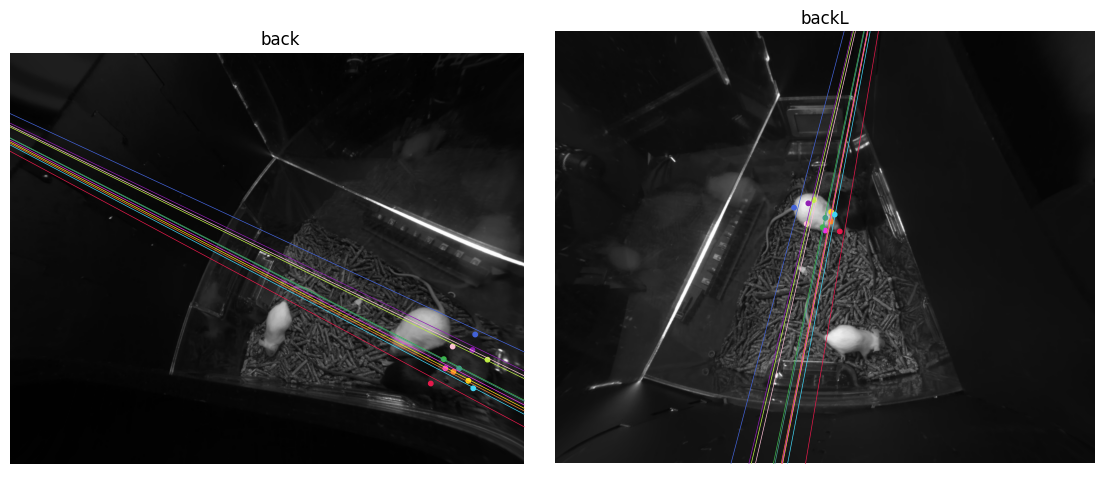

In [ ]:
visual_frame_debug(sft, 'back', 'backL', (2, 0))


frame num: 899
(array([[  1.77260886,  50.3678629 ,  48.62262881],
       [ 47.06927617,   1.91265025,  69.44190809],
       [ 40.93110403, 119.37562519,   8.94395454]]), ('mid', 'top'))
8.943954544955442


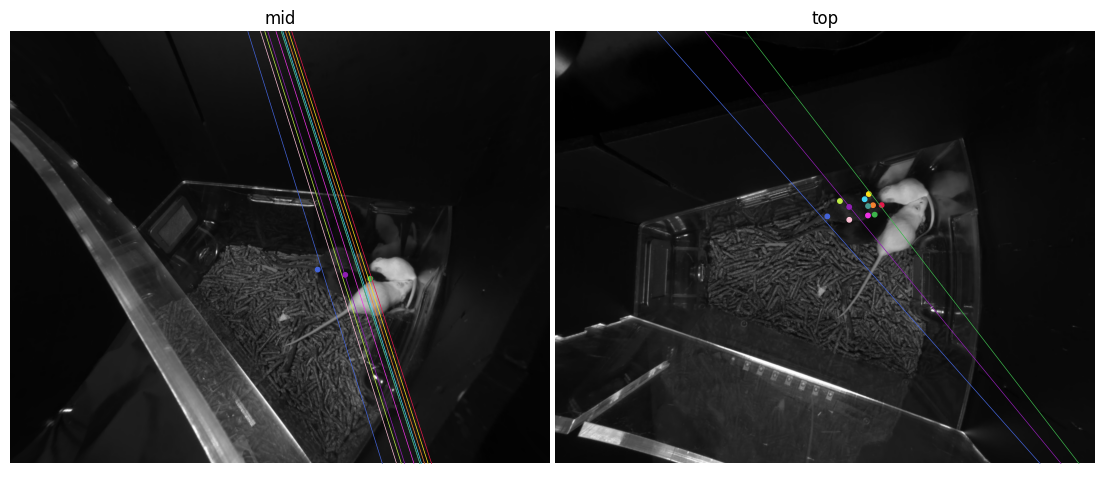

In [ ]:
# frame 899
# in this case, top: t1 should be its own singleton group

visual_frame_debug(sft, 'mid', 'top', (2, 2))
# print(sft.fg.instances['back'][3].points)

frame num: 472
(array([[  2.21941964, 121.31560732,  62.00328392],
       [ 79.21389215,   3.49462984,   6.35363296]]), ('midL', 'top'))
6.353632964617938


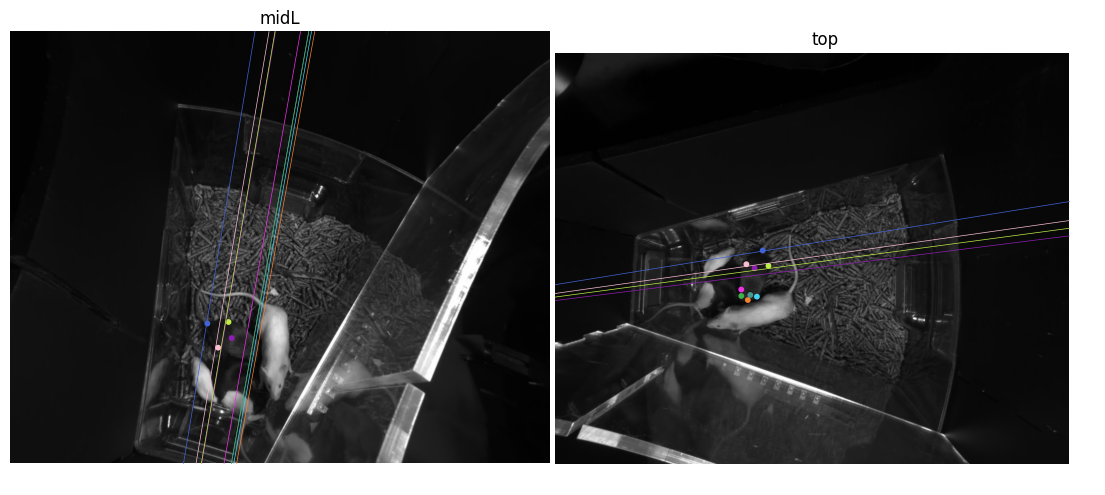

In [ ]:
# frame 472
# in this case, top: t1 should be its own singleton group

visual_frame_debug(sft, 'midL', 'top', (1, 2))
# print(sft.fg.instances['back'][3].points)

frame num: 116
(array([[  4.84548216, 127.03099776,  55.75103293],
       [102.87371196,   2.27860429,  68.71268699],
       [  4.46436679, 121.58571348,  51.06407123],
       [ 55.47930853,  91.80342775,   3.23139932]]), ('back', 'backL'))
4.464366785243815


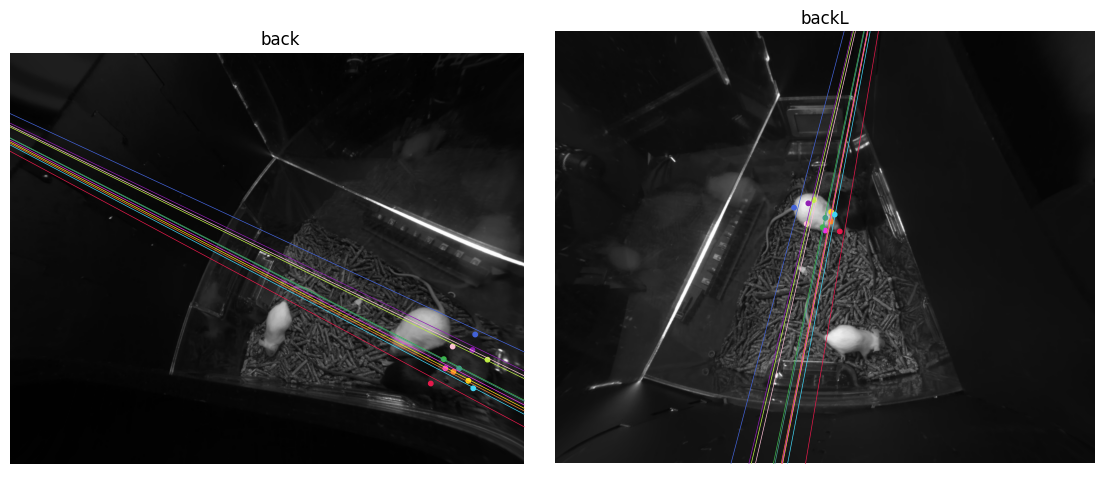

In [ ]:
# frame 116!!!!!
visual_frame_debug(sft, 'back', 'backL', (2, 0))

# Tracker - Subsequent Frame ID Assignment

In [4]:
track_push.reset_identities(window)
importlib.reload(tracker)
importlib.reload(geometry)
importlib.reload(track_push)
results = track_push.track_pusher(
    window=window,
    frame_indices=range(session.max_frame),
    node_weights=node_weights
)

# issues: frame 212
print(f'invalid frames: {[r['sft'].frame_idx for r in results if not r['sft'].valid]}')

push: 100%|██████████| 1799/1799 [00:09<00:00, 191.09it/s]

invalid frames: []


In [ ]:
track_push.reset_identities(window)
importlib.reload(tracker)
importlib.reload(geometry)

# make a 'null' frame
session.frame_group(50).instances  = {}

mft = tracker.MultiFrameTrack(
    window=window,
    node_weights=node_weights
)
mft.track(verbose=True)
mft.push_assignments_to_gui()

100%|██████████| 1799/1799 [00:09<00:00, 196.95it/s]


Num invalid instances                 262
Num nonmatch instances                657
Num nonmatch groups                     0
Num nonmatch group instances            0

Total Instances                     39151
Fraction Valid                    0.99331
Fraction Matched Single           0.98322
Fraction Matched With Group       0.98322


In [ ]:
'''
frame 971 with all equal node weights:

costs = [  8.46867227, 132.8065604 , 145.57581932,  99.75397819],
        [235.7543993 , 123.66224871, 293.76710505, 279.02444588],
        [134.97044012, 143.15137734,   2.86266423,  58.93571779],
        [100.26218739, 193.63076845,  59.67690845,   2.54510588],
        [128.80282373,  11.69184899, 160.76899348, 192.01329553]])


frame 971 with all nonequal node weights:

costs = [ 11.88703017,  85.67977838, 111.03540541,  73.61893596],
        [ 88.44584177,   9.28871522,  95.6056907 , 138.5897645 ],
        [116.3029404 ,  97.52757302,   2.84730707,  60.41996567],
        [ 74.47101032, 141.01829521,  60.67313209,   2.64108067]])
'''


In [ ]:
'''
quick todo list:
1. my own push framer 
2. swap detection thing
3. quick debugger viewer
4. push
5. find out why luc3d tracker sucks
6. push to luc3d
'''

# Single Frame Smart Hungarian

In [4]:
node_weights = {
    'Nose':   0.7,
    'Ear_R':  0.7,
    'Ear_L':  0.7,
    'TTI':    1,
    'TailTip':0,
    'Head':   1,
    'Trunk':  0.8,
    'Tail_0': 0,
    'Tail_1': 0,
    'Tail_2': 0,
    'Shoulder_left':  0.7,
    'Shoulder_right': 0.7,
    'Haunch_left':    0.7,
    'Haunch_right':   0.7,
    'Neck': 0.7
}

In [13]:
result = track_push.track_pusher(
    window=window,
    frame_indices=range(115, 116),
    node_weights=node_weights
)
groups, assignments, adj, inst_list, sft = track_push.push_frame_assignments(
    window, 116,
    palette=palette, node_weights=node_weights,
    prev_trackIds=result[0]['sft'].trackIds, max_id=4,
)

trackIds @ 115:
  id=0  valid=True  cam_track=[('back', 0), ('backL', 0), ('mid', 0), ('midL', 0), ('top', 0), ('topL', 0)]
  id=1  valid=True  cam_track=[('back', 1), ('backL', 1), ('mid', 1), ('midL', 1), ('top', 1), ('topL', 1)]
  id=2  valid=True  cam_track=[('back', 2), ('mid', 2), ('midL', 2), ('top', 2), ('topL', 2)]
  id=3  valid=True  cam_track=[('back', 3), ('backL', 3), ('mid', 3), ('midL', 3), ('topL', 3)]

adjacency_matrix : shape=(22, 22), finite edges=49
instance_list    : 22 entries

identities       : [(0, 'id_0', '#e41a1c'), (1, 'id_1', '#377eb8'), (2, 'id_2', '#4daf4a'), (3, 'id_3', '#984ea3')]
color_mode       : identity
current_frame    : 115
stored bundle?   : True
map@frame_idx    : {'115:back:0': 0, '115:backL:0': 0, '115:mid:0': 0, '115:midL:0': 0, '115:top:0': 0, '115:topL:0': 0, '115:back:1': 1, '115:backL:1': 1, '115:mid:1': 1, '115:midL:1': 1, '115:top:1': 1, '115:topL:1': 1, '115:back:2': 2, '115:mid:2': 2, '115:midL:2': 2, '115:top:2': 2, '115:topL:2': 2,

In [219]:
importlib.reload(tracker)
groups, assignments, adj, inst_list, sft = track_push.push_frame_assignments(
    window, 472,
    palette=palette, node_weights=node_weights,
    prev_trackIds=None, max_id=4)
[g.valid for g in sft.groups]
sft.groups[0].cams_by_count

[] ('back', 'backL')
[] ('back', 'mid')
[] ('back', 'midL')
[] ('back', 'top')
[] ('back', 'topL')
[] ('backL', 'mid')
[] ('backL', 'midL')
[] ('backL', 'top')
[] ('backL', 'topL')
[] ('mid', 'midL')
[] ('mid', 'top')
[] ('mid', 'topL')
[(1, 1), (1, 2)] ('midL', 'top')
[] ('midL', 'topL')
[] ('top', 'topL')


defaultdict(int,
            {'back': 1, 'backL': 1, 'mid': 1, 'midL': 1, 'top': 1, 'topL': 1})

In [221]:
sft.match_conflicts

[(7, 9), (7, 10)]

In [112]:
sft.get_edges('backL', 'back')

(array([[  4.84548216, 127.03099776,  55.75103293],
        [102.87371196,   2.27860429,  68.71268699],
        [  4.46436679, 121.58571348,  51.06407123],
        [ 55.47930853,  91.80342775,   3.23139932]]),
 ('back', 'backL'))

In [162]:

# sft.smart_hungarian(edges = edges)
sft.instance_by_cam['back']
sft.instance_by_cam['backL'][2]

(6,
 array([[         nan,          nan],
        [660.74766552, 373.02619415],
        [654.61874639, 407.61641376],
        [732.91875598, 469.94483199],
        [652.72683124, 393.35477447],
        [712.97710993, 423.63930793],
        [660.81895763, 417.89609912],
        [676.87318869, 383.33460468],
        [690.98459142, 458.08568121],
        [729.2990552 , 427.6232392 ],
        [663.05465253, 395.58187384]]))

In [227]:
def find_disjoint_graphs(adj_matrix, bad_edges=None):
    n_nodes = adj_matrix.shape[0]

    parent = {n: n for n in range(n_nodes)}
    cam_to_id = {c.name: i for i, c in enumerate(sft.cameras)}
    camera_ids = [cam_to_id[tup[1]] for tup in sft.instance_list]

    cameras_in_component = {n: {camera_ids[n]} for n in range(n_nodes)}


    def find(i):
        if parent[i] == i: return i
        parent[i] = find(parent[i])
        return parent[i]

    def union(i, j):
        root_i = find(i)
        root_j = find(j)
        if root_i != root_j:
            parent[root_i] = root_j
            cameras_in_component[root_j].update(cameras_in_component[root_i])

    bad_edges = {frozenset(edge) for edge in bad_edges}

    for i in range(n_nodes):
        for j in range(n_nodes):
            if adj_matrix[i][j] != np.inf and frozenset({i, j}) not in bad_edges:
            # if adj_matrix[i][j] != np.inf:
                union(i, j)

    # find all groups
    distinct_groups = defaultdict(list)
    for node in range(n_nodes):
        root = find(node)
        distinct_groups[root].append(node)


    return distinct_groups
    
groups = find_disjoint_graphs(sft.adjacency_matrix, sft.match_conflicts)
sft.groups[1].cam_track

[('back', 2),
 ('backL', 2),
 ('mid', 2),
 ('midL', 2),
 ('top', 2),
 ('topL', 2),
 ('top', 1)]

In [230]:
list(groups.values())


[[0, 2, 4, 6, 8, 11], [1, 3, 5, 7, 10, 12], [9]]

# Graph Algorithms

In [18]:
track_push.reset_identities(window)
importlib.reload(tracker)
importlib.reload(geometry)
importlib.reload(track_push)
results = track_push.track_pusher(
    window=window,
    frame_indices=[899],
    node_weights=node_weights
)
sft = results[0]['sft']
# issues: frame 212
print(f'invalid frames: {[r['sft'].frame_idx for r in results if not r['sft'].valid]}')

trackIds @ 899:
  id=0  valid=True  cam_track=[('back', 0), ('backL', 0), ('mid', 0), ('midL', 0), ('top', 0), ('topL', 0)]
  id=1  valid=True  cam_track=[('back', 1), ('backL', 1), ('mid', 1), ('midL', 1), ('top', 1), ('topL', 1)]
  id=2  valid=True  cam_track=[('back', 3), ('mid', 3), ('midL', 3), ('topL', 3)]
  id=3  valid=True  cam_track=[('backL', 2), ('midL', 2), ('top', 2), ('topL', 2)]

adjacency_matrix : shape=(20, 20), finite edges=43
instance_list    : 20 entries

identities       : [(0, 'id_0', '#e41a1c'), (1, 'id_1', '#377eb8'), (2, 'id_2', '#4daf4a'), (3, 'id_3', '#984ea3')]
color_mode       : identity
current_frame    : 899
stored bundle?   : True
map@frame_idx    : {'899:back:0': 0, '899:backL:0': 0, '899:mid:0': 0, '899:midL:0': 0, '899:top:0': 0, '899:topL:0': 0, '899:back:1': 1, '899:backL:1': 1, '899:mid:1': 1, '899:midL:1': 1, '899:top:1': 1, '899:topL:1': 1, '899:back:3': 2, '899:mid:3': 2, '899:midL:3': 2, '899:topL:3': 2, '899:backL:2': 3, '899:midL:2': 3, '899:

In [19]:
sft.valid

True

In [20]:
importlib.reload(graphs)
sft = results[0]['sft']
# sft.adjacency_matrix
group = graphs._run_union_find(
    sft.adjacency_matrix,
    sft.cameras,
    sft.instance_list,
    sft.match_conflicts,
    sft.cam_map,
    sft.proj_cache
)

new_groups = graphs._fix_group(
    group,
    sft.adjacency_matrix,
    sft.cameras,
    sft.instance_list,
    sft.match_conflicts,
    sft.cam_map,
    sft.proj_cache
)
print(group)
print(new_groups)
for e in new_groups:
    print(e)

[2, 5, 8, 11, 12, 15, 18, 19]
[[2, 8, 12, 19], [5, 11, 15, 18]]
[2, 8, 12, 19]
[5, 11, 15, 18]


In [44]:
sft.adjacency_matrix[2]

array([       inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf, 2.46472935,        inf,        inf,        inf,
              inf,        inf, 6.39783902,        inf])

In [34]:
cam_to_id = {cam.name: i for i, cam in enumerate(sft.cameras)}
cam_to_id
# camera_ids = [cam_to_id[t[1]]for t in sft.instance_list]
# cameras_in_component = {n: {camera_ids[n]} for n in group}

{'back': 0, 'backL': 1, 'mid': 2, 'midL': 3, 'top': 4, 'topL': 5}